<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


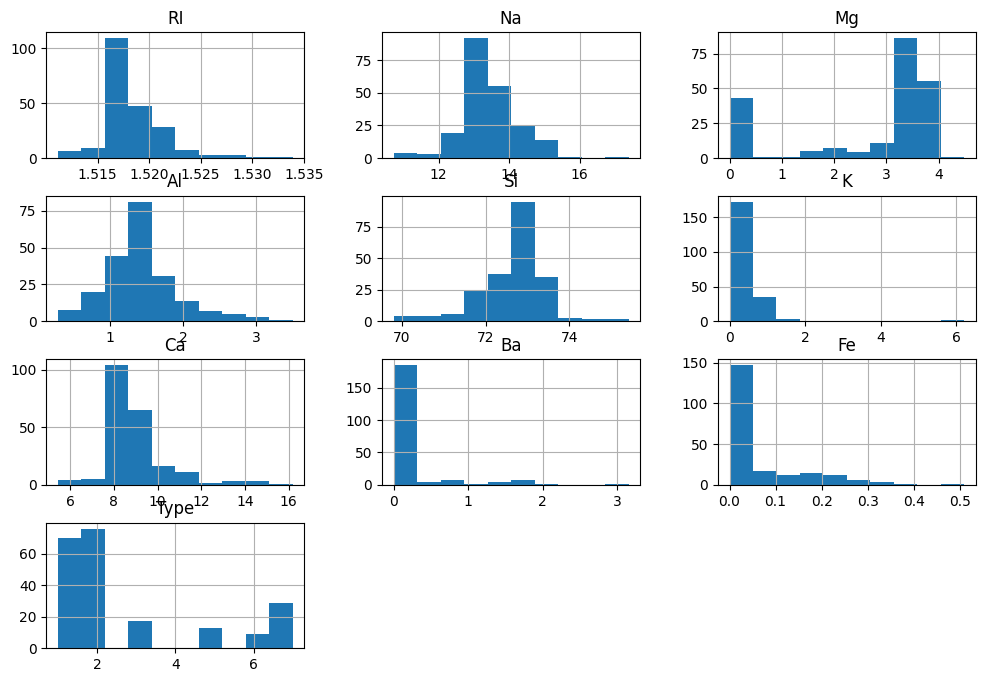

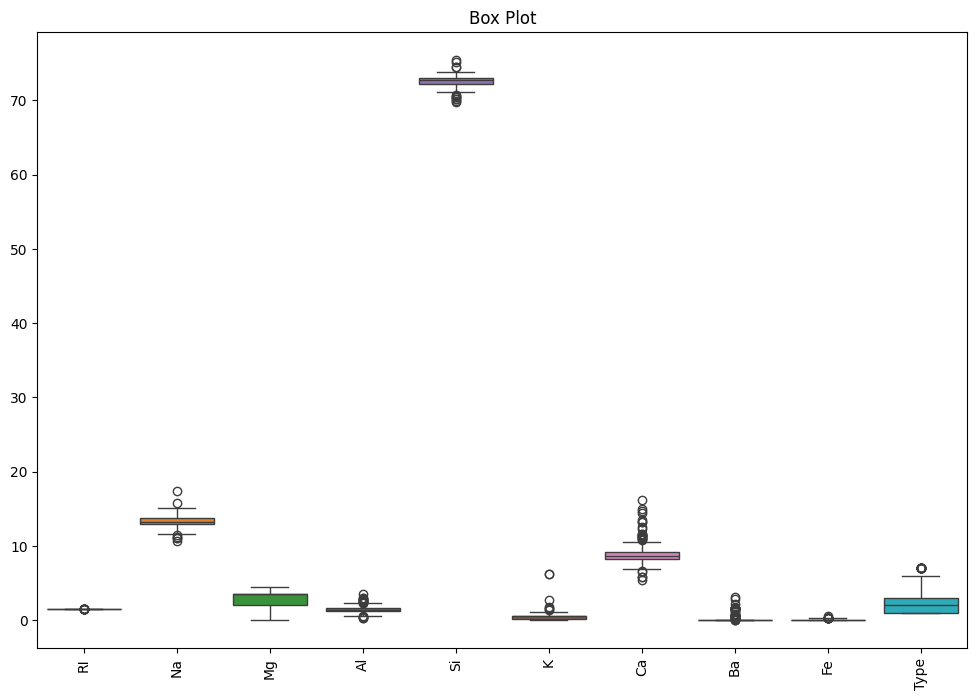

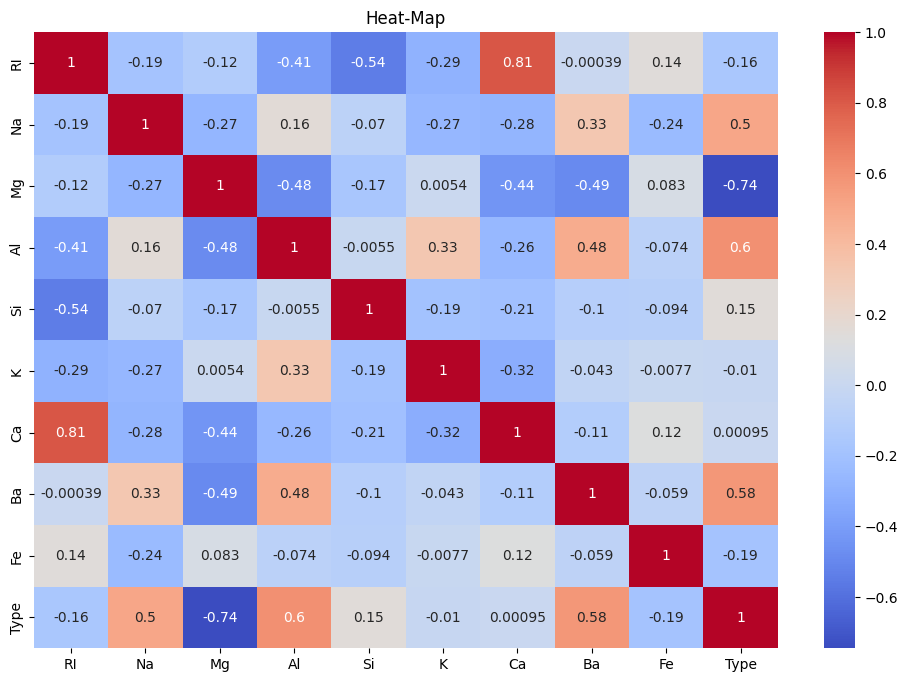

Accuracy: 0.813953488372093

Classification Report:

              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.79      0.73      0.76        15
           3       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.81        43
   macro avg       0.87      0.85      0.84        43
weighted avg       0.83      0.81      0.81        43


Confusion Matrix:

[[12  2  0  0  0  0]
 [ 3 11  0  0  1  0]
 [ 1  0  2  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  2  0]
 [ 0  1  0  0  0  5]]


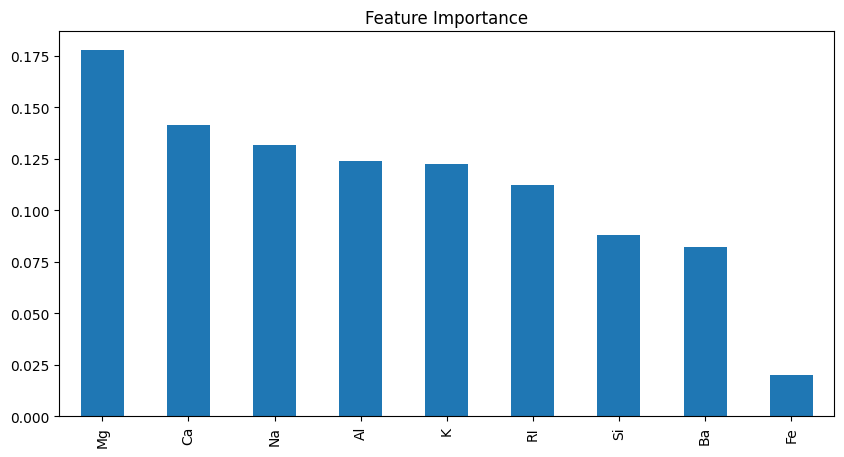

In [2]:
import numpy as np
import pandas as pd

df=pd.read_excel(r"/content/glass.xlsx", sheet_name="glass")

df.shape

df.info()

df.describe()

df.head()

df.isnull().sum()

df["Type"].value_counts()

import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.title("Box Plot")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Heat-Map")
plt.show()

X=df.drop("Type", axis=1)
y=df["Type"]
X=X.fillna(X.mean())

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
y.value_counts(normalize=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
    X_scaled,y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # handles imbalance
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()


In [1]:
'''
Bagging (Bootstrap Aggregating)
Bagging is an ensemble learning technique that improves model performance by combining predictions from multiple models trained on different random samples of the dataset.

Steps in Bagging:
1.Multiple subsets of the training data are created using bootstrap sampling (sampling with replacement).
2.A separate model is trained on each subset.
3.Predictions from all models are combined (averaging for regression or majority voting for classification).

Boosting
Boosting is another ensemble learning technique where models are trained sequentially, and each new model focuses on correcting the errors made by the previous models.

Steps in Boosting:
1.Train a model on the dataset.
2.Identify the misclassified or difficult samples.
3.Give higher importance (weights) to those samples.
4.Train the next model focusing more on those errors.
5.Combine all models to produce the final prediction.

2. How to Handle Imbalanced Data
Imbalanced data occurs when one class has significantly more samples than the other class.

Example:
Fraud detection
Disease prediction
Spam detection
If not handled properly, the model may favor the majority class.

Methods to Handle Imbalanced Data
1. Oversampling
Increase the number of samples in the minority class.

Common techniques:
Random Oversampling
SMOTE (Synthetic Minority Oversampling Technique)
SMOTE generates synthetic samples instead of duplicating data.

2. Undersampling
Reduce the number of samples in the majority class.

Example:
Randomly remove samples from the majority class.

Advantage:
Faster training

Disadvantage:
Loss of information.

3. Using Different Evaluation Metrics
Accuracy alone may not work well for imbalanced data. Instead use:

Precision
Recall
F1 Score
ROC-AUC

4. Class Weight Adjustment
Some algorithms allow assigning higher weight to minority class samples so the model pays more attention to them.

Example in models:
Logistic Regression
Random Forest
SVM

Imbalanced datasets can lead to biased predictions.
Techniques like oversampling, undersampling, SMOTE, and class weighting help balance the dataset and improve model performance.
'''

'\nBagging (Bootstrap Aggregating)\nBagging is an ensemble learning technique that improves model performance by combining predictions from multiple models trained on different random samples of the dataset.\n\nSteps in Bagging:\n1.Multiple subsets of the training data are created using bootstrap sampling (sampling with replacement).\n2.A separate model is trained on each subset.\n3.Predictions from all models are combined (averaging for regression or majority voting for classification).\n\nBoosting\nBoosting is another ensemble learning technique where models are trained sequentially, and each new model focuses on correcting the errors made by the previous models.\n\nSteps in Boosting:\n1.Train a model on the dataset.\n2.Identify the misclassified or difficult samples.\n3.Give higher importance (weights) to those samples.\n4.Train the next model focusing more on those errors.\n5.Combine all models to produce the final prediction.\n\n2. How to Handle Imbalanced Data\nImbalanced data oc